# 基础 SEIR 模型示例

这个示例演示：
- 用 SEIR 常微分方程描述传染病传播
- 使用 `solve_ivp` 进行数值求解
- 画出 `S/E/I/R` 随时间变化曲线

C:\Users\HP\AppData\Local\Temp\ipykernel_47220\2295101881.py:58: UserWarning: Glyph 26102 (\N{CJK UNIFIED IDEOGRAPH-65F6}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_47220\2295101881.py:58: UserWarning: Glyph 38388 (\N{CJK UNIFIED IDEOGRAPH-95F4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_47220\2295101881.py:58: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_47220\2295101881.py:58: UserWarning: Glyph 22825 (\N{CJK UNIFIED IDEOGRAPH-5929}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_47220\2295101881.py:58: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\HP\AppData\Local\Temp\ipykernel_47220\2295101881.py:58: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDE

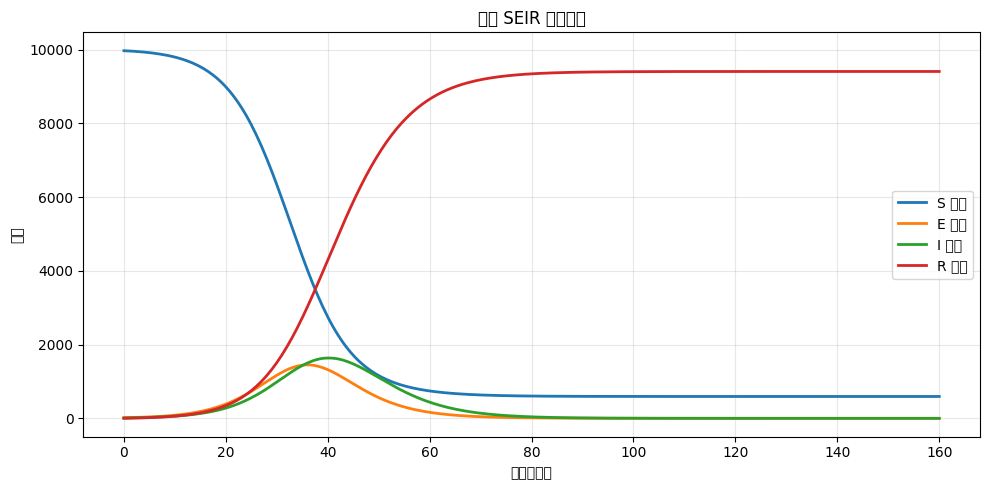

感染峰值人数: 1636
感染峰值时间: 40.0 天


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# 总人口
N = 10000

# 传播参数
beta = 0.6      # 传播率
gamma = 0.2     # 恢复率
sigma = 0.25    # 潜伏转感染率

# 初始状态
I0 = 10
E0 = 20
R0 = 0
S0 = N - I0 - E0 - R0
y0 = [S0, E0, I0, R0]

# 时间范围（天）
t_start, t_end = 0, 160
t_eval = np.linspace(t_start, t_end, 321)


def seir_rhs(t, y, beta, sigma, gamma, n):
    s, e, i, r = y
    ds = -beta * s * i / n
    de = beta * s * i / n - sigma * e
    di = sigma * e - gamma * i
    dr = gamma * i
    return [ds, de, di, dr]


sol = solve_ivp(
    fun=seir_rhs,
    t_span=(t_start, t_end),
    y0=y0,
    t_eval=t_eval,
    args=(beta, sigma, gamma, N),
    method="RK45",
)

if not sol.success:
    raise RuntimeError(f"求解失败: {sol.message}")

S, E, I, R = sol.y

plt.figure(figsize=(10, 5))
plt.plot(sol.t, S, label="S 易感", linewidth=2)
plt.plot(sol.t, E, label="E 潜伏", linewidth=2)
plt.plot(sol.t, I, label="I 感染", linewidth=2)
plt.plot(sol.t, R, label="R 康复", linewidth=2)
plt.title("基础 SEIR 传播曲线")
plt.xlabel("时间（天）")
plt.ylabel("人数")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

peak_idx = int(np.argmax(I))
print(f"感染峰值人数: {I[peak_idx]:.0f}")
print(f"感染峰值时间: {sol.t[peak_idx]:.1f} 天")